In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

from datasets import load_dataset

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [2]:
dataset = load_dataset(
    'FronkonGames/steam-games-dataset',
    split='train'
)

df_raw = dataset.to_pandas()

print('Dataset berhasil dimuat')
print(f'Jumlah baris : {len(df_raw):,}')
print(f'Jumlah kolom : {len(df_raw.columns)}')

df_raw.head(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.29k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/192M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/124146 [00:00<?, ? examples/s]

Dataset berhasil dimuat
Jumlah baris : 124,146
Jumlah kolom : 41


,appID,name,release_date,estimated_owners,peak_ccu,required_age,price,dlc_count,detailed_description,short_description,...,median_playtime_forever,median_playtime_2weeks,developers,publishers,categories,genres,tags,screenshots,movies,packages
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,,,...,0,0,[],[],[],[],[],[https://shared.akamai.steamstatic.com/store_i...,[],[]
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,0,"Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",...,8,0,[minori],[MangaGamer],"[Single-player, Steam Trading Cards, Steam Clo...",[Adventure],[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy Supipara - Chapter 1 Spring Ha..."
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,"Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,...,0,0,[Somer Games],[8floor],"[Single-player, Family Sharing]",[Casual],[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy Mystery Solitaire The Black Ra..."


In [3]:
import os

# Create the 'dataset' directory if it doesn't exist
if not os.path.exists('dataset'):
    os.makedirs('dataset')

# Simpan dataset mentah
df_raw.to_csv('dataset/steam_games_raw.csv', index=False)
print('Dataset mentah disimpan ke dataset/steam_games_raw.csv')
print('\n Kolom yang tersedia:')
print(df_raw.columns.tolist())

Dataset mentah disimpan ke dataset/steam_games_raw.csv

 Kolom yang tersedia:
['appID', 'name', 'release_date', 'estimated_owners', 'peak_ccu', 'required_age', 'price', 'dlc_count', 'detailed_description', 'short_description', 'supported_languages', 'full_audio_languages', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'user_score', 'positive', 'negative', 'score_rank', 'achievements', 'recommendations', 'notes', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'developers', 'publishers', 'categories', 'genres', 'tags', 'screenshots', 'movies', 'packages']


In [4]:
df = df_raw.copy()

In [5]:
# Pilih kolom yang relevan
cols_needed = [
    'appID',
    'name',
    'release_date',
    'price',
    'positive',
    'negative',
    'peak_ccu',
    'recommendations',
    'achievements',
    'genres',
    'categories',
    'tags',
    'windows',
    'mac',
    'linux',
    'average_playtime_forever',
    'median_playtime_forever',
    'estimated_owners'
]

df = df[cols_needed]

df.head(3)

,appID,name,release_date,price,positive,negative,peak_ccu,recommendations,achievements,genres,categories,tags,windows,mac,linux,average_playtime_forever,median_playtime_forever,estimated_owners
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0.00,0,0,0,0,0,[],[],[],True,False,False,0,0,0 - 0
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",5.24,252,3,0,231,0,[Adventure],"[Single-player, Steam Trading Cards, Steam Clo...",[],True,False,False,8,8,0 - 20000
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",4.99,21,3,0,0,0,[Casual],"[Single-player, Family Sharing]",[],True,True,False,0,0,0 - 20000


In [6]:
# INFO DASAR DATASET
print('='*50)
print('INFO DATASET')
print('='*50)
print(df.info())
print('\n STATISTIK DESKRIPTIF')
print(df.describe())

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124146 entries, 0 to 124145
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   appID                     124146 non-null  object 
 1   name                      124146 non-null  object 
 2   release_date              124146 non-null  object 
 3   price                     124146 non-null  float64
 4   positive                  124146 non-null  int64  
 5   negative                  124146 non-null  int64  
 6   peak_ccu                  124146 non-null  int64  
 7   recommendations           124146 non-null  int64  
 8   achievements              124146 non-null  int64  
 9   genres                    124146 non-null  object 
 10  categories                124146 non-null  object 
 11  tags                      124146 non-null  object 
 12  windows                   124146 non-null  bool   
 13  mac                       12414

In [7]:
#Check Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
print('\n Missing Values:')
print(missing_df)


 Missing Values:
Empty DataFrame
Columns: [Missing, Percentage]
Index: []


In [8]:
numeric_cols = [
    'price',
    'positive',
    'negative',
    'peak_ccu',
    'recommendations',
    'achievements',
    'average_playtime_forever',
    'median_playtime_forever'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [9]:
def midpoint(owner_range):

    low, high = owner_range.split('-')

    low = int(
        low.replace(',', '').strip()
    )

    high = int(
        high.replace(',', '').strip()
    )

    return (low + high) / 2

In [10]:
df['estimated_owners_mid'] = (
    df['estimated_owners']
    .apply(midpoint)
)

In [11]:
df['total_reviews'] = (
    df['positive'] + df['negative']
)

df['positive_ratio'] = (
    df['positive'] /
    (df['total_reviews'] + 1)
)

In [12]:
df['engagement_score'] = (
    df['average_playtime_forever'] *
    np.log1p(df['peak_ccu'])
)

In [13]:
model_cols = [
    'price',
    'positive_ratio',
    'estimated_owners_mid',
    'peak_ccu',
    'recommendations',
    'engagement_score'
]

df = df.dropna(subset=model_cols)

In [14]:
# 1. Apply log transformation
log_features = np.log1p(df[
    [
        'estimated_owners_mid',
        'peak_ccu',
        'recommendations',
        'engagement_score'
    ]
])

# 2. Scale the log features
scaler = MinMaxScaler()
scaled = scaler.fit_transform(log_features)

In [15]:
scaled_df = pd.DataFrame(
    scaled,
    columns=[
        'owners_norm',
        'ccu_norm',
        'recommendations_norm',
        'engagement_norm'
    ]
)

df = pd.concat(
    [df.reset_index(drop=True), scaled_df],
    axis=1
)

In [16]:
df['market_impact_score'] = (
    0.30 * df['owners_norm'] +
    0.25 * df['ccu_norm'] +
    0.20 * df['engagement_norm'] +
    0.15 * df['recommendations_norm'] +
    0.10 * df['positive_ratio']
)

In [17]:
def success_tier(score):

    if score < 0.20:
        return 'Failure'

    elif score < 0.40:
        return 'Moderate'

    elif score < 0.60:
        return 'Successful'

    elif score < 0.80:
        return 'Hit'

    else:
        return 'Generational Hit'

In [18]:
df['success_label'] = (
    df['market_impact_score']
    .apply(success_tier)
)

In [19]:
df[
    [
        'name',
        'market_impact_score',
        'success_label'
    ]
].head(10)

,name,market_impact_score,success_label
0,Black Dragon Mage Playtest,0.000000,Failure
1,Supipara - Chapter 1 Spring Has Come!,0.298294,Moderate
2,Mystery Solitaire The Black Raven,0.230771,Moderate
3,버튜버 파라노이아 - Vtuber Paranoia,0.159301,Failure
4,Maze Quest VR,0.146771,Failure
5,Agony VR,0.146771,Failure
6,Armored Brigade II,0.428115,Successful
7,Galacatraz: Eject Equip Escape,0.146771,Failure
8,Hepta Beats,0.231619,Moderate
9,MUMBA IV: Egypt Jewels,0.232378,Moderate


# **Exploratory Data Analysis (EDA)**

In [20]:
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')

Rows    : 124,146
Columns : 28


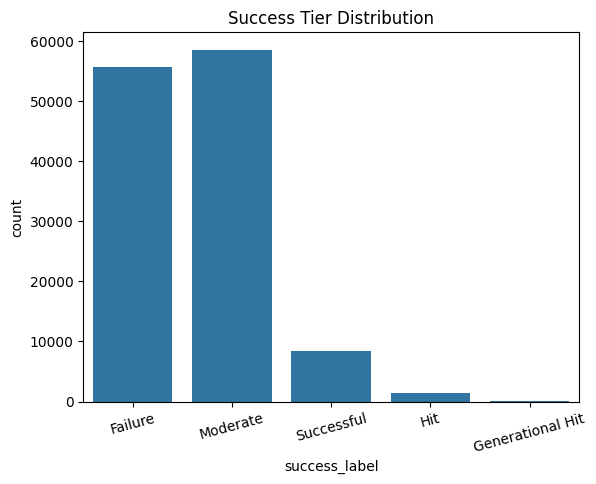

In [21]:
df.head()

sns.countplot(
    data=df,
    x='success_label'
)

plt.title('Success Tier Distribution')

plt.xticks(rotation=15)

plt.show()

In [22]:
# Print the exact count of games in each tier
print("--- Raw Counts ---")
print(df['success_label'].value_counts())

# Print the percentages (super helpful for your analysis)
print("\n--- Percentages ---")
print(round(df['success_label'].value_counts(normalize=True) * 100, 2).astype(str) + '%')

--- Raw Counts ---
success_label
Moderate            58554
Failure             55689
Successful           8479
Hit                  1366
Generational Hit       58
Name: count, dtype: int64

--- Percentages ---
success_label
Moderate            47.17%
Failure             44.86%
Successful           6.83%
Hit                   1.1%
Generational Hit     0.05%
Name: proportion, dtype: object


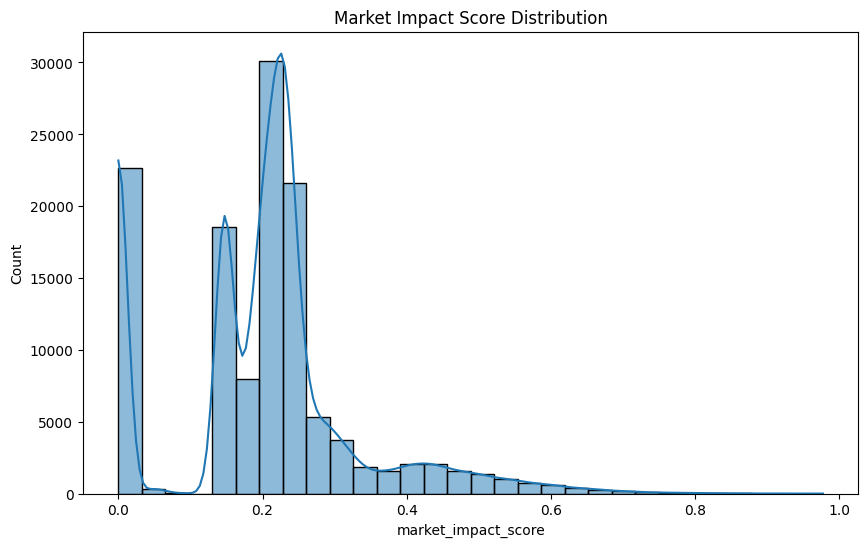

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['market_impact_score'],
    bins=30,
    kde=True
)

plt.title('Market Impact Score Distribution')

plt.show()

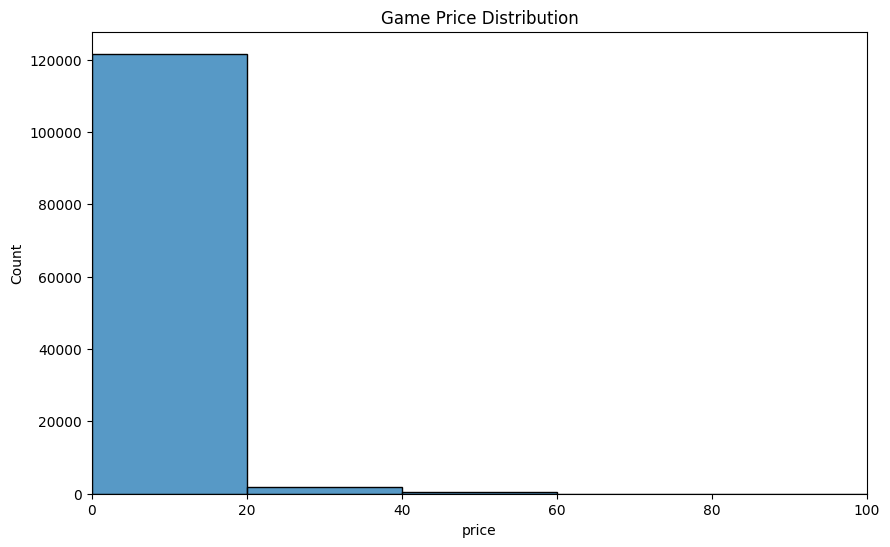

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['price'],
    bins=50
)

plt.xlim(0,100)

plt.title('Game Price Distribution')

plt.show()

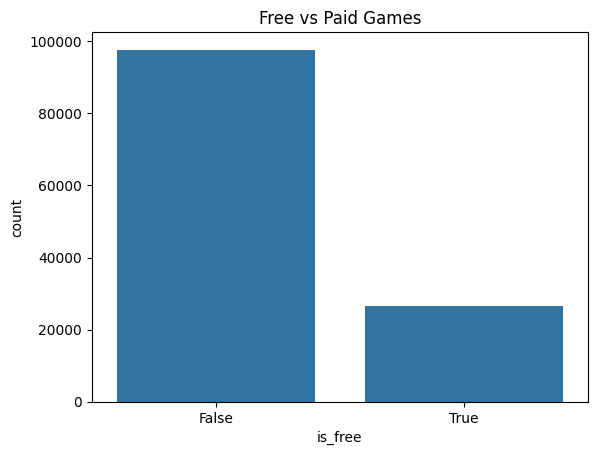

In [25]:
df['is_free'] = df['price'] == 0

sns.countplot(
    data=df,
    x='is_free'
)

plt.title('Free vs Paid Games')

plt.show()

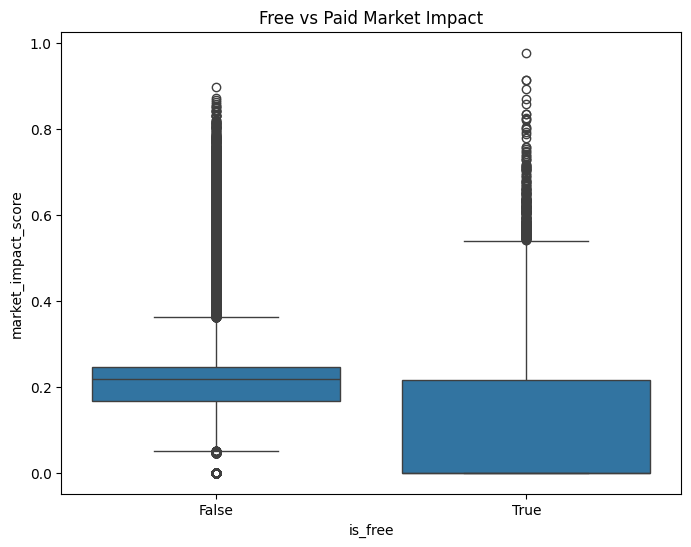

In [26]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='is_free',
    y='market_impact_score'
)

plt.title('Free vs Paid Market Impact')

plt.show()

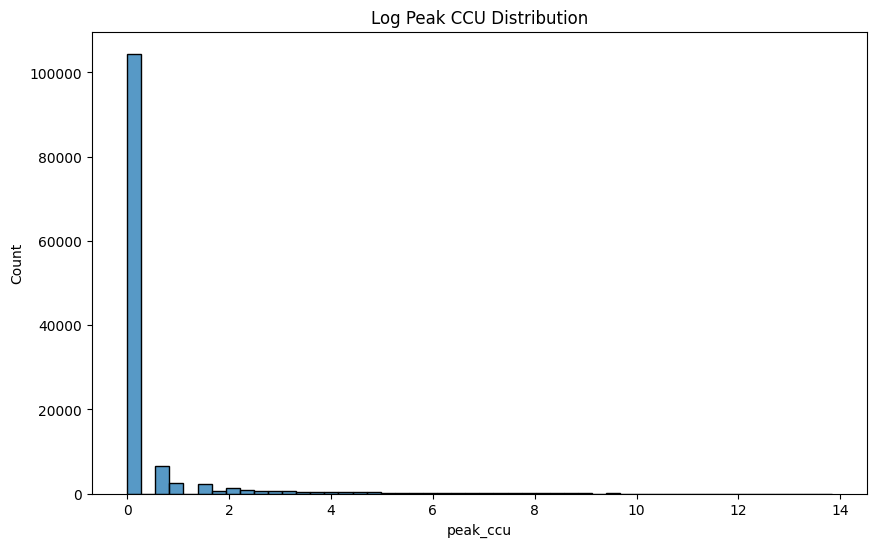

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(df['peak_ccu']),
    bins=50
)

plt.title('Log Peak CCU Distribution')

plt.show()

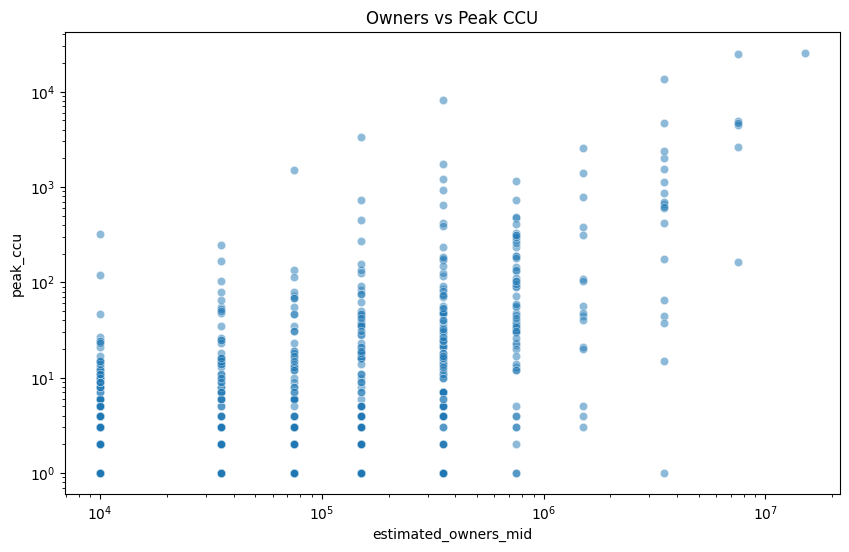

In [28]:
sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x='estimated_owners_mid',
    y='peak_ccu',
    alpha=0.5
)

plt.xscale('log')
plt.yscale('log')

plt.title('Owners vs Peak CCU')

plt.show()

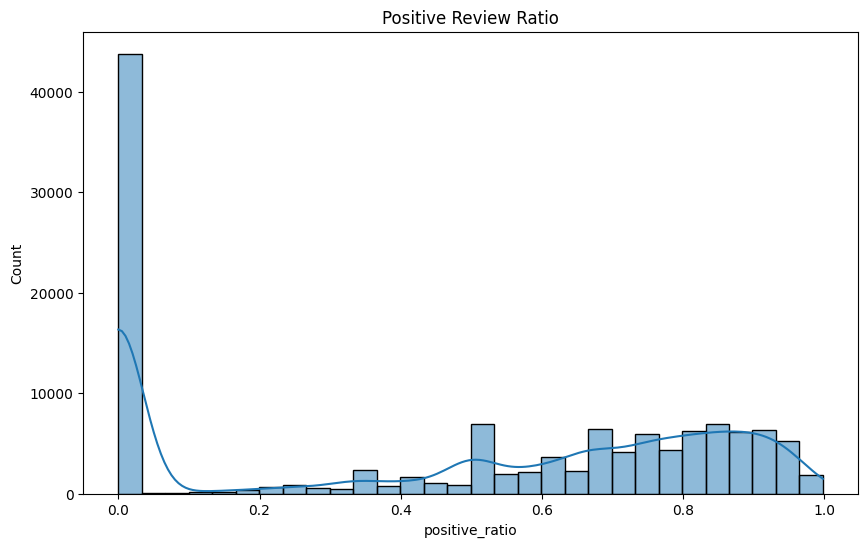

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['positive_ratio'],
    bins=30,
    kde=True
)

plt.title('Positive Review Ratio')

plt.show()

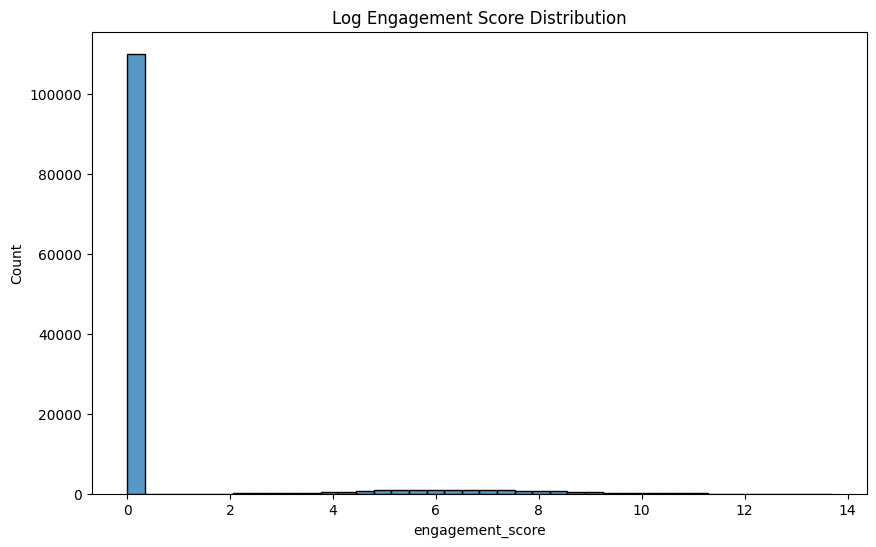

In [30]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(df['engagement_score']),
    bins=40
)

plt.title('Log Engagement Score Distribution')

plt.show()

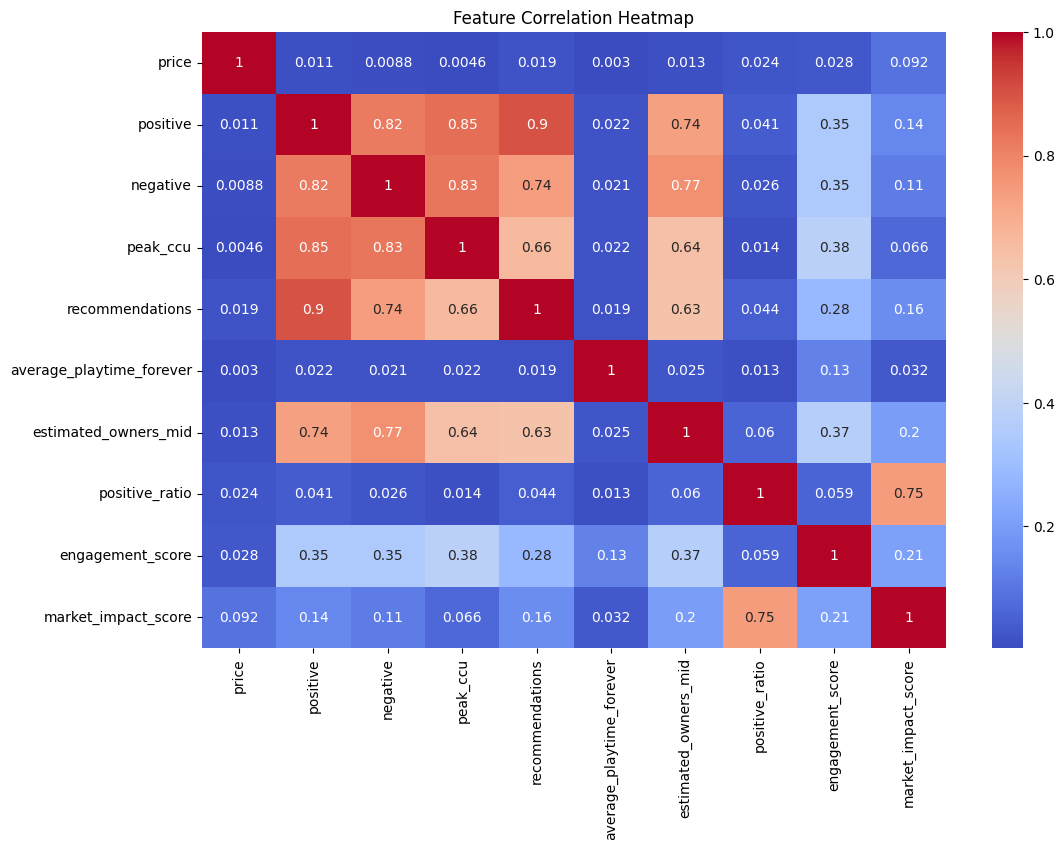

In [31]:
eda_cols = [
    'price',
    'positive',
    'negative',
    'peak_ccu',
    'recommendations',
    'average_playtime_forever',
    'estimated_owners_mid',
    'positive_ratio',
    'engagement_score',
    'market_impact_score'
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df[eda_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.show()

In [32]:
genre_df = df.copy()

genre_df = genre_df.explode('genres')

genre_df['genres'] = genre_df['genres'].astype(str)

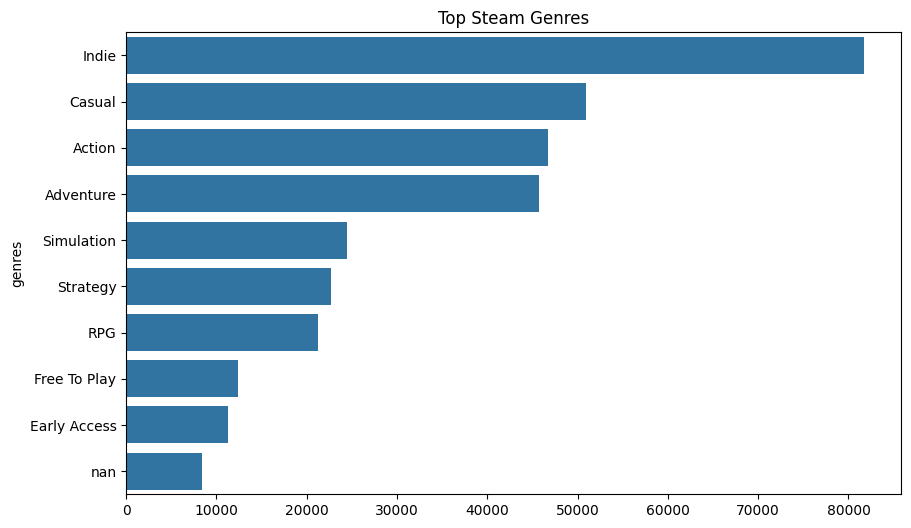

In [33]:
top_genres = (
    genre_df['genres']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top Steam Genres')

plt.show()

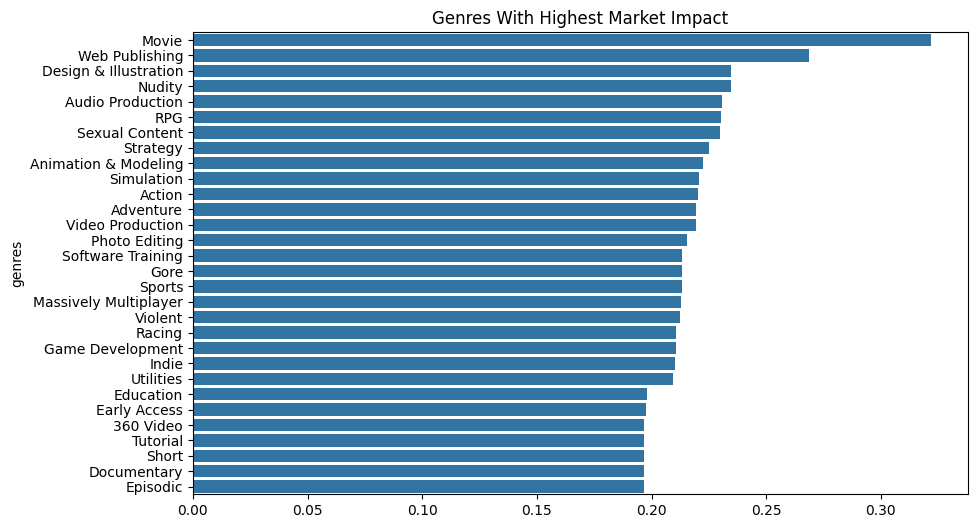

In [34]:
genre_impact = (
    genre_df
    .groupby('genres')['market_impact_score']
    .mean()
    .sort_values(ascending=False)
    .head(30)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=genre_impact.values,
    y=genre_impact.index
)

plt.title('Genres With Highest Market Impact')

plt.show()

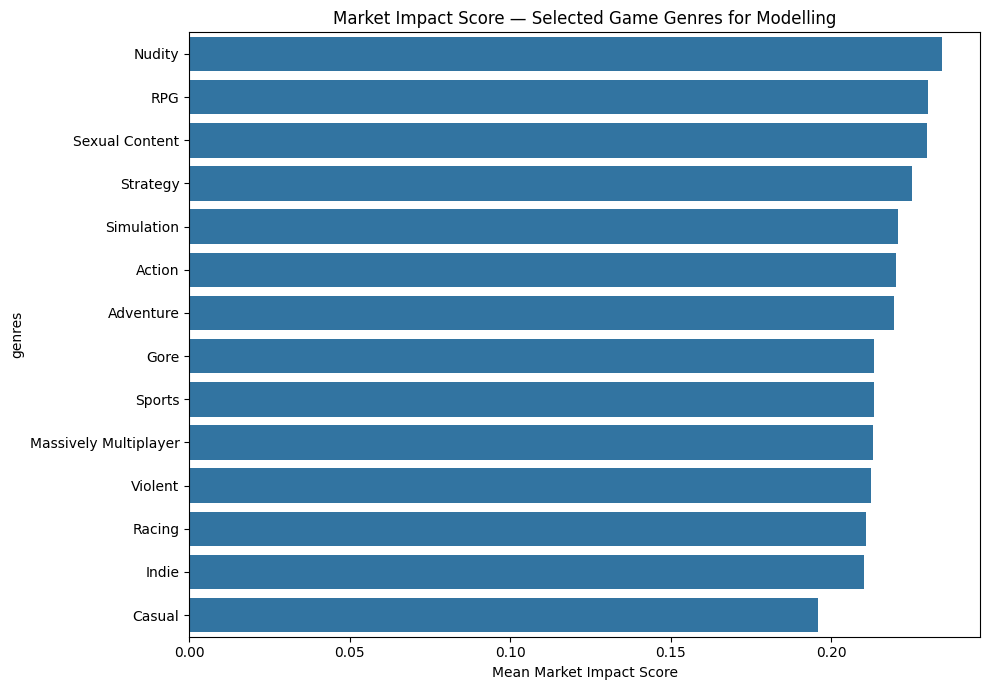

In [35]:
# Game-relevant genres selected for modelling — based on EDA market impact + coverage
SELECTED_GENRES_NOTE = [
    'Action', 'Adventure', 'Casual', 'Indie',
    'RPG', 'Simulation', 'Strategy',
    'Sports', 'Racing', 'Nudity', 'Gore',
    'Violent', 'Sexual Content', 'Massively Multiplayer'
]

genre_selected_impact = (
    genre_df[genre_df['genres'].isin(SELECTED_GENRES_NOTE)]
    .groupby('genres')['market_impact_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 7))
sns.barplot(x=genre_selected_impact.values, y=genre_selected_impact.index)
plt.title('Market Impact Score — Selected Game Genres for Modelling')
plt.xlabel('Mean Market Impact Score')
plt.tight_layout()
plt.show()

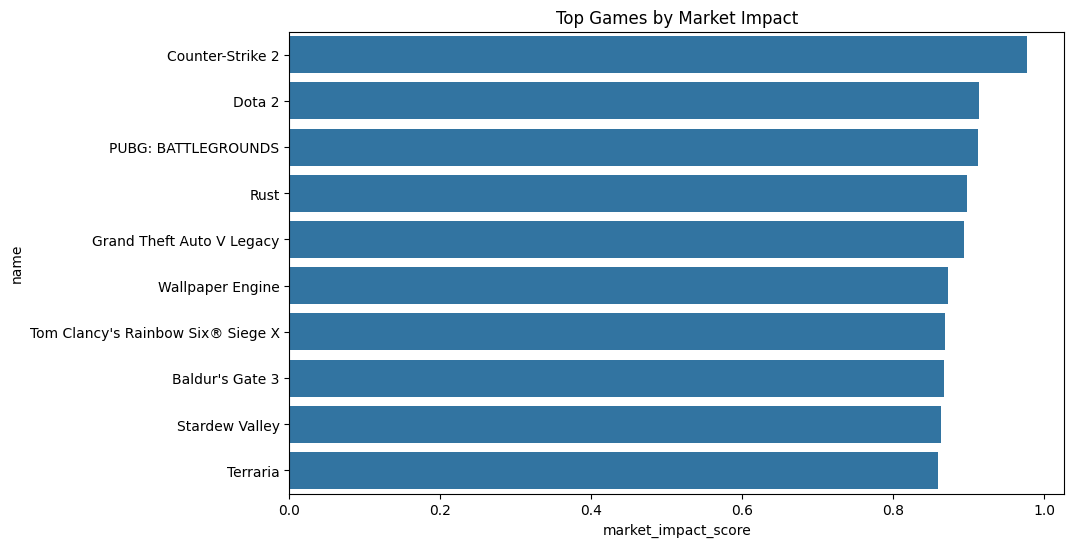

In [36]:
top_games = (
    df[
        [
            'name',
            'market_impact_score'
        ]
    ]
    .sort_values(
        by='market_impact_score',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_games,
    x='market_impact_score',
    y='name'
)

plt.title('Top Games by Market Impact')

plt.show()

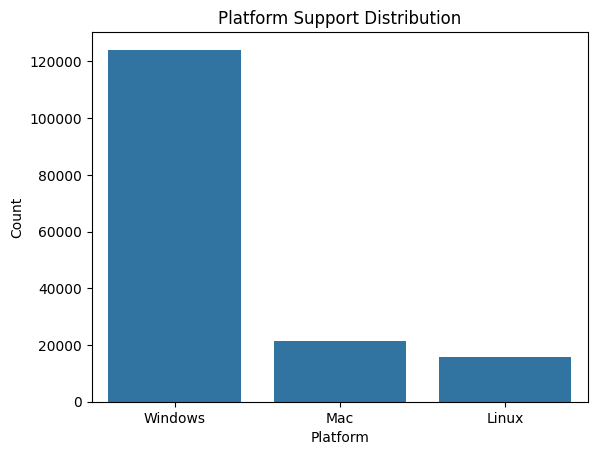

In [37]:
platform_counts = {
    'Windows': df['windows'].sum(),
    'Mac': df['mac'].sum(),
    'Linux': df['linux'].sum()
}

platform_df = pd.DataFrame({
    'Platform': platform_counts.keys(),
    'Count': platform_counts.values()
})

sns.barplot(
    data=platform_df,
    x='Platform',
    y='Count'
)

plt.title('Platform Support Distribution')

plt.show()

Removed extreme outliers. Remaining games: 123,208


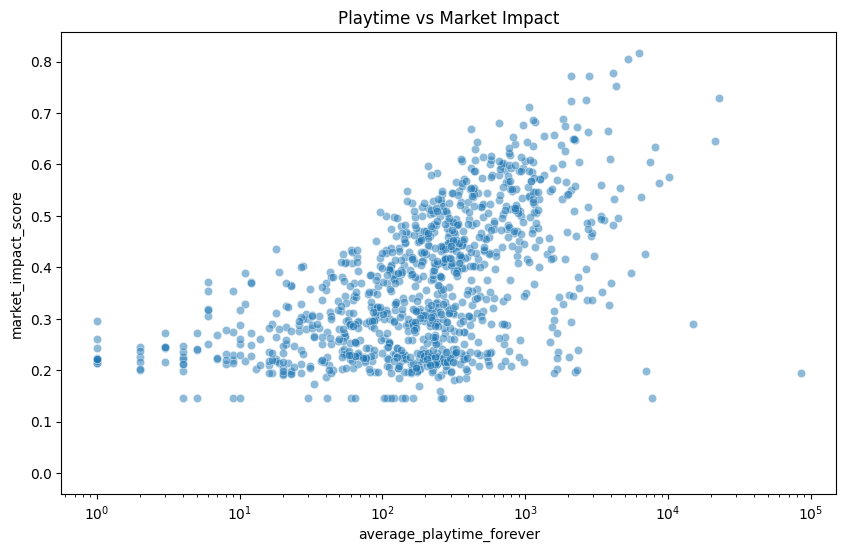

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x='average_playtime_forever',
    y='market_impact_score',
    alpha=0.5
)

df_cluster = df[
    (df['price'] <= 100) &
    (df['estimated_owners_mid'] <= df['estimated_owners_mid'].quantile(0.99))
].copy()

print(f"Removed extreme outliers. Remaining games: {len(df_cluster):,}")

plt.xscale('log')

plt.title('Playtime vs Market Impact')

plt.show()

Menghitung Elbow Method (Optimized)...
  K=2: Inertia=1046, Silhouette=0.6124
  K=3: Inertia=679, Silhouette=0.6480
  K=4: Inertia=364, Silhouette=0.6629
  K=5: Inertia=216, Silhouette=0.6316
  K=6: Inertia=176, Silhouette=0.5918

Statistik per Cluster:
         price  achievements  platform_count  total_reviews  positive_ratio  \
Cluster                                                                       
0         5.46         10.47             1.0          10.60            0.06   
1         4.21         20.38             1.0         128.06            0.73   
2         1.51          6.92             1.0           0.00            0.00   
3         7.08         41.70             1.0        3498.30            0.82   

         release_year  Count  Success_Rate  
Cluster                                     
0             2022.61  26827           0.2  
1             2020.73  61371           0.0  
2             2024.01  22908           0.0  
3             2019.32  12102          76.0  



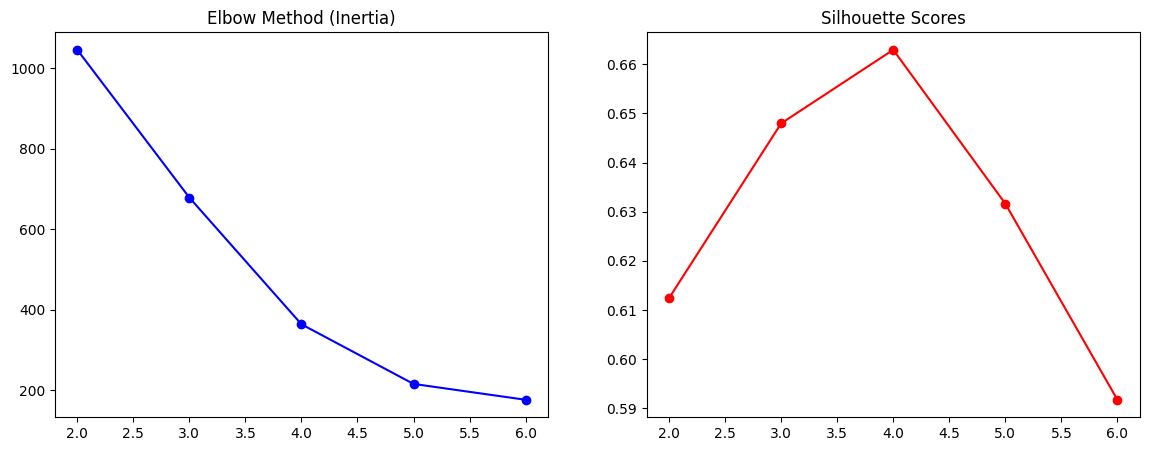

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Define and fit scaler for price
scaler_price = MinMaxScaler()
df_cluster['price_norm'] = scaler_price.fit_transform(df_cluster[['price']])

# Prepare data for clustering
X_cluster = df_cluster[['price_norm', 'engagement_norm', 'owners_norm', 'positive_ratio']].values

# 1. Sub-sample for Elbow
sample_size = min(15000, len(X_cluster))
X_sample = X_cluster[np.random.choice(len(X_cluster), sample_size, replace=False)]

print('Menghitung Elbow Method (Optimized)...')
inertias, silhouettes = [], []
K_range = range(2, 7) # Reduced range to focus on the elbow
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, km.labels_))
    print(f'  K={k}: Inertia={km.inertia_:.0f}, Silhouette={silhouettes[-1]:.4f}')

# 2. Final Fit (Full Dataset)
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10).fit(X_cluster)
df_cluster['Cluster'] = kmeans.labels_

# 4. ANALISIS & INTERPRETASI CLUSTER
# Rebuild missing metrics for the summary table
if 'Success_Target' not in df_cluster.columns:
    success_tiers = ['Successful', 'Hit', 'Generational Hit']
    df_cluster['Success'] = df_cluster['success_label'].apply(lambda x: 1 if x in success_tiers else 0)
else:
    df_cluster['Success'] = df_cluster['Success_Target']

if 'platform_count' not in df_cluster.columns:
    df_cluster['platform_count'] = df_cluster['windows'] + df_cluster['mac'] + df_cluster['linux']
if 'total_reviews' not in df_cluster.columns:
    df_cluster['total_reviews'] = df_cluster['positive'] + df_cluster['negative']

# Create the exact summary table format you requested
cluster_features = ['price', 'achievements', 'platform_count', 'total_reviews', 'positive_ratio']
# Note: assuming 'positive_ratio' is your 'positive_rate'
cluster_summary = df_cluster.groupby('Cluster')[cluster_features].mean().round(2)
cluster_summary['release_year'] = pd.to_datetime(df_cluster['release_date'], errors='coerce').dt.year.groupby(df_cluster['Cluster']).mean().round(2)
cluster_summary['Count'] = df_cluster['Cluster'].value_counts().sort_index()
cluster_summary['Success_Rate'] = df_cluster.groupby('Cluster')['Success'].mean().round(3) * 100

print('\nStatistik per Cluster:')
print(cluster_summary)

# 5. AUTO-LABELING BERDASARKAN KARAKTERISTIK
# Sort by: Price, Reviews, Positive_Ratio, Achievements
cluster_rank = cluster_summary[['price', 'total_reviews', 'positive_ratio', 'achievements']].copy()
cluster_rank_norm = (cluster_rank - cluster_rank.min()) / (cluster_rank.max() - cluster_rank.min() + 1e-9)

# Buat skor komposit
cluster_rank_norm['score'] = (
    cluster_rank_norm['total_reviews'] * 0.4 +
    cluster_rank_norm['positive_ratio'] * 0.3 +
    cluster_rank_norm['achievements'] * 0.2 +
    cluster_rank_norm['price'] * 0.1
)

sorted_clusters = cluster_rank_norm['score'].sort_values(ascending=False).index.tolist()

# Assign labels: highest score = Hardcore Niche, then Casual Hits, Meme Games, Abandoned
label_assign = ['Hardcore Niche', 'Casual Hits', 'Meme/Viral Games', 'Abandoned Projects']
CLUSTER_NAMES = {c: label_assign[i] for i, c in enumerate(sorted_clusters)}

df_cluster['Cluster_Name'] = df_cluster['Cluster'].map(CLUSTER_NAMES)
# Also map it to market_archetype so your charts still work!
df_cluster['market_archetype'] = df_cluster['Cluster_Name']

print('\n Label Cluster:')
for k, v in CLUSTER_NAMES.items():
    print(f'  Cluster {k}: {v}')


# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-'); axes[0].set_title('Elbow Method (Inertia)')
axes[1].plot(K_range, silhouettes, 'ro-'); axes[1].set_title('Silhouette Scores')
plt.show()

In [40]:
# --- Master Cell 2: The Logic Core ---
# 1. Fit Final Model (K=4)
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_cluster)

# 2. Composite Score Auto-Labeling
cluster_summary = df_cluster.groupby('Cluster')[['price', 'total_reviews', 'positive_ratio', 'achievements']].median()
cluster_rank_norm = (cluster_summary - cluster_summary.min()) / (cluster_summary.max() - cluster_summary.min() + 1e-9)
cluster_rank_norm['score'] = (
    cluster_rank_norm['total_reviews']*0.4 +
    cluster_rank_norm['positive_ratio']*0.3 +
    cluster_rank_norm['achievements']*0.2 +
    cluster_rank_norm['price']*0.1
)

# 3. Apply Dynamic Names
sorted_clusters = cluster_rank_norm['score'].sort_values(ascending=False).index.tolist()
label_assign = ['Market Leaders', 'Casual Hits', 'Meme/Viral Games', 'Abandoned Projects']
archetype_map = {c: label_assign[i] for i, c in enumerate(sorted_clusters)}

df_cluster['market_archetype'] = df_cluster['Cluster'].map(archetype_map)

# 4. Print Summary
print(f"--- Market Archetype Profiles (K={K_OPTIMAL}) ---")
print(df_cluster.groupby('market_archetype').agg({
    'price': 'median', 'estimated_owners_mid': 'median',
    'engagement_score': 'median', 'market_archetype': 'count'
}).rename(columns={'market_archetype': 'total_games'}))

--- Market Archetype Profiles (K=4) ---
                    price  estimated_owners_mid  engagement_score  total_games
market_archetype                                                              
Abandoned Projects   0.00                   0.0          0.000000        22908
Casual Hits          2.49               10000.0          0.000000        61371
Market Leaders       4.99               75000.0        601.651753        12102
Meme/Viral Games     2.99               10000.0          0.000000        26827


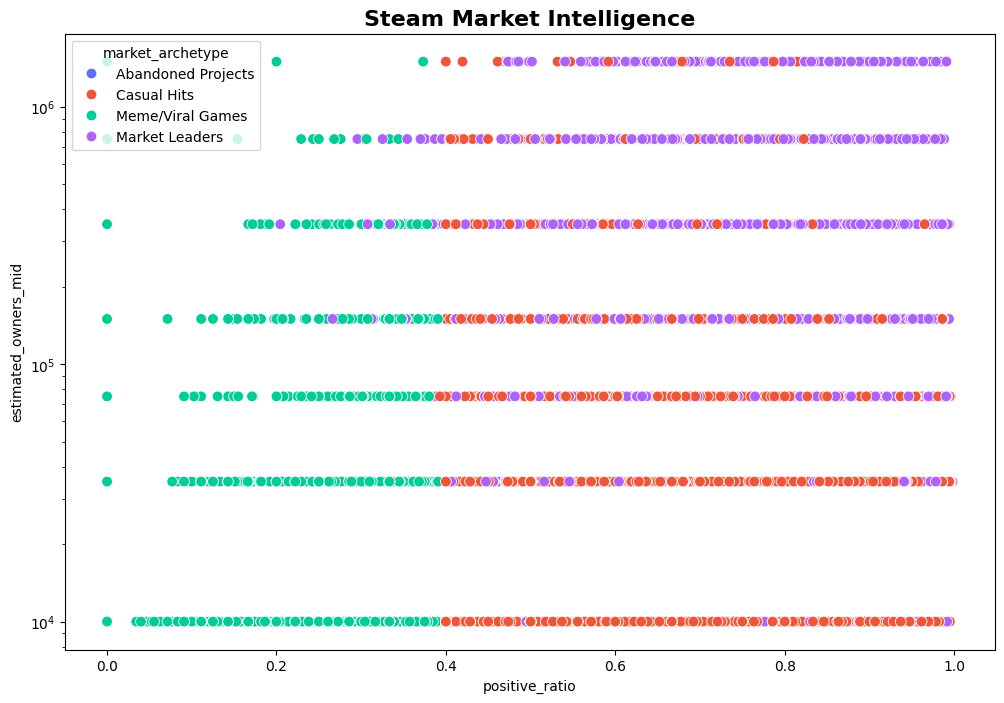

In [41]:
# --- Master Cell 3: The Visualization Suite ---
# 1. 2D Scatter

# Define your professional palette
color_map = {
    'Market Leaders': '#AB63FA',
    'Casual Hits': '#EF553B',
    'Meme/Viral Games': '#00CC96',
    'Abandoned Projects': '#636EFA'
}
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_cluster,
    x='positive_ratio',
    y='estimated_owners_mid',
    hue='market_archetype',
    palette=color_map, # This forces the colors to match
    s=60
)
plt.yscale('log')
plt.title('Steam Market Intelligence', fontsize=16, fontweight='bold')
plt.show()

# 2. 3D Plot
df_cluster['log_owners'] = np.log1p(df_cluster['estimated_owners_mid'])
df_cluster['log_ccu'] = np.log1p(df_cluster['peak_ccu'])

# 2. Now call the plot using the COLUMN NAMES
fig = px.scatter_3d(
    df_cluster,
    x='positive_ratio',
    y='log_owners',
    z='log_ccu',
    color='market_archetype',
    title='3D Market Ecosystem: Quality vs Scale vs Hype',
    labels={
        'positive_ratio': 'Market Reception (Positive Ratio)',
        'log_owners': 'Scale (Log Owners)',
        'log_ccu': 'Hype (Log Peak CCU)'
    }
)

# 3. Add consistent formatting
fig.update_traces(marker=dict(size=3))
fig.show()

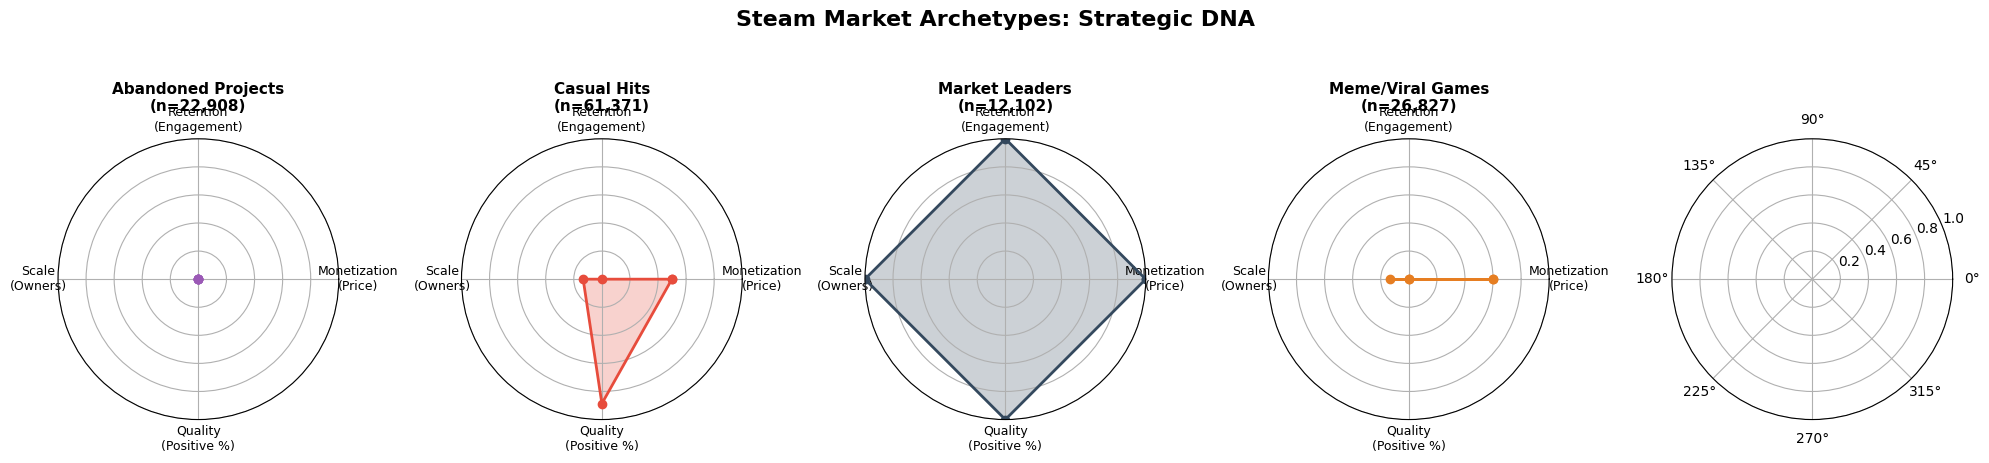

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Group the data to get the median values for our radar chart
cluster_summary = df_cluster.groupby('market_archetype')[
    ['price', 'engagement_score', 'estimated_owners_mid', 'positive_ratio']
].median()

# Normalize the summary data between 0 and 1 so it fits perfectly on a radar chart
radar_data = (cluster_summary - cluster_summary.min()) / (cluster_summary.max() - cluster_summary.min() + 1e-9)
categories = ['Monetization\n(Price)', 'Retention\n(Engagement)', 'Scale\n(Owners)', 'Quality\n(Positive %)']

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Close the loop

# Setup the figure
fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw=dict(polar=True))
colors = ['#9b59b6', '#e74c3c', '#34495e', '#e67e22', '#2ecc71'] # Custom hex colors

for idx, (archetype, row) in enumerate(radar_data.iterrows()):
    ax = axes[idx]
    values = row.tolist()
    values += values[:1] # Close the loop

    ax.plot(angles, values, 'o-', linewidth=2, color=colors[idx])
    ax.fill(angles, values, alpha=0.25, color=colors[idx])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticklabels([]) # Hide the concentric circle numbers for a cleaner look

    # Get the game count for the title
    count = len(df_cluster[df_cluster['market_archetype'] == archetype])
    ax.set_title(f'{archetype}\n(n={count:,})', size=11, fontweight='bold', pad=20)

plt.suptitle('Steam Market Archetypes: Strategic DNA', fontsize=16, fontweight='bold', y=1.1)
plt.tight_layout()
plt.show()

In [43]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

ml_df = df.copy()

# 1. Define the Binary Target (Success = 1, Not Success = 0)
success_tiers = ['Successful', 'Hit', 'Generational Hit']
ml_df['Success_Target'] = ml_df['success_label'].apply(lambda x: 1 if x in success_tiers else 0)

# 2. Rebuild missing features
ml_df['platform_count'] = ml_df['windows'] + ml_df['mac'] + ml_df['linux']
ml_df['genre_count'] = ml_df['genres'].astype(str).apply(lambda x: len(x.split(',')) if x != 'nan' else 0)

# Parse release dates
ml_df['release_parsed'] = pd.to_datetime(ml_df['release_date'], errors='coerce')
ml_df['release_year'] = ml_df['release_parsed'].dt.year.fillna(ml_df['release_parsed'].dt.year.median())
ml_df['release_month'] = ml_df['release_parsed'].dt.month.fillna(ml_df['release_parsed'].dt.month.median())

# 3. Expanded genre list — strictly game genres, data-backed from EDA
TOP_GENRES = [
    'Action', 'Adventure', 'Casual', 'Indie',
    'RPG', 'Simulation', 'Strategy',
    'Sports', 'Racing',
    'Nudity', 'Gore', 'Violent',
    'Sexual Content',
    'Massively Multiplayer',
]

for g in TOP_GENRES:
    ml_df[f'genre_{g}'] = ml_df['genres'].astype(str).apply(lambda x: 1 if g in x else 0)

# 4. Genre interaction combos — only keeping those with >0.5% dataset coverage
# Dropped: Action_Violent (0.2%), Action_Gore (0.1%), Nudity_Sexual Content (0.0%),
#          Nudity_Indie (0.1%), Violent_Gore (0.2%) — too sparse for model to learn from
GENRE_COMBOS = [
    ('RPG',    'Massively Multiplayer'),  # 0.9% — MMORPG archetype
    ('Action', 'Massively Multiplayer'),  # 1.3% — live action MMO
    ('Sports', 'Racing'),                 # 1.1% — often co-tagged
]

for g1, g2 in GENRE_COMBOS:
    col1 = f'genre_{g1}'
    col2 = f'genre_{g2}'
    if col1 in ml_df.columns and col2 in ml_df.columns:
        ml_df[f'combo_{g1}_{g2}'] = ml_df[col1] * ml_df[col2]

combo_cols = [f'combo_{g1}_{g2}' for g1, g2 in GENRE_COMBOS]

print(f"Combo features added ({len(combo_cols)}): {combo_cols}")
print("\nCombo coverage in dataset:")
for col in combo_cols:
    count = ml_df[col].sum()
    pct = count / len(ml_df) * 100
    print(f"  {col}: {count:,} games ({pct:.1f}%)")

# 5. Define feature list — base features + genre flags + interaction combos
feature_cols = [
    'price', 'is_free', 'achievements', 'platform_count',
    'release_year', 'release_month', 'genre_count'
] + [f'genre_{g}' for g in TOP_GENRES] + combo_cols

ml_df = ml_df.dropna(subset=feature_cols + ['Success_Target'])

print(f"\nFeatures mapped ({len(feature_cols)}): {feature_cols}")

Combo features added (3): ['combo_RPG_Massively Multiplayer', 'combo_Action_Massively Multiplayer', 'combo_Sports_Racing']

Combo coverage in dataset:
  combo_RPG_Massively Multiplayer: 1,126 games (0.9%)
  combo_Action_Massively Multiplayer: 1,566 games (1.3%)
  combo_Sports_Racing: 1,347 games (1.1%)

Features mapped (24): ['price', 'is_free', 'achievements', 'platform_count', 'release_year', 'release_month', 'genre_count', 'genre_Action', 'genre_Adventure', 'genre_Casual', 'genre_Indie', 'genre_RPG', 'genre_Simulation', 'genre_Strategy', 'genre_Sports', 'genre_Racing', 'genre_Nudity', 'genre_Gore', 'genre_Violent', 'genre_Sexual Content', 'genre_Massively Multiplayer', 'combo_RPG_Massively Multiplayer', 'combo_Action_Massively Multiplayer', 'combo_Sports_Racing']


In [44]:
X = ml_df[feature_cols].values
y = ml_df['Success_Target'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Original Train set: {X_train.shape[0]:,} records')
print(f'Original Distribution: Success={y_train.sum():,} | Not Success={(len(y_train) - y_train.sum()):,}')

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE Train set: {X_train_res.shape[0]:,} records')
print(f'New Distribution: {pd.Series(y_train_res).value_counts().to_dict()}')

Original Train set: 99,316 records
Original Distribution: Success=7,922 | Not Success=91,394

After SMOTE Train set: 182,788 records
New Distribution: {0: 91394, 1: 91394}


In [45]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

# Initialize the 3 models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42) # Increased max_iter for convergence
}

results = {}
for name, model in models.items():
    # Train
    model.fit(X_train_res, y_train_res)
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    # Score
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {'accuracy': acc, 'auc': auc, 'model': model, 'y_pred': y_pred, 'y_prob': y_prob}
    print(f'{name}: Accuracy = {acc:.4f} | AUC = {auc:.4f}')

# Determine the winner based on AUC
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_model = results[best_model_name]['model']
print(f'\n Best Model: {best_model_name}')

print(f'\n=== EVALUATION: {best_model_name} ===')
print(classification_report(y_test, results[best_model_name]['y_pred'], target_names=['Not Success', 'Success']))

Random Forest: Accuracy = 0.9265 | AUC = 0.8688
Gradient Boosting: Accuracy = 0.9152 | AUC = 0.8732
Logistic Regression: Accuracy = 0.6889 | AUC = 0.7654

 Best Model: Gradient Boosting

=== EVALUATION: Gradient Boosting ===
              precision    recall  f1-score   support

 Not Success       0.95      0.96      0.95     22849
     Success       0.46      0.38      0.41      1981

    accuracy                           0.92     24830
   macro avg       0.70      0.67      0.68     24830
weighted avg       0.91      0.92      0.91     24830



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



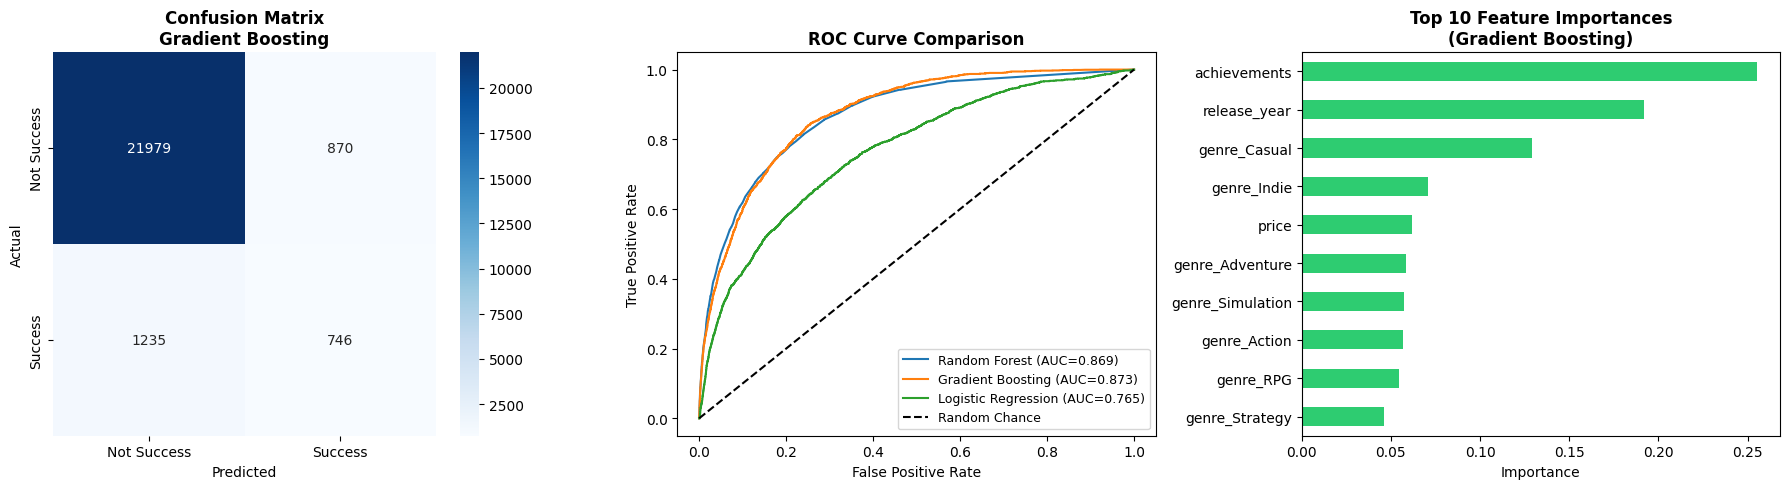

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
y_pred_best = results[best_model_name]['y_pred']
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Success', 'Success'],
            yticklabels=['Not Success', 'Success'])
axes[0].set_title(f'Confusion Matrix\n{best_model_name}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. ROC Curve
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Chance')
axes[1].set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9, loc='lower right')

# 3. Feature Importance (Using the winning model if tree-based)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)
    feat_imp.tail(10).plot(kind='barh', ax=axes[2], color='#2ecc71')
    axes[2].set_title(f'Top 10 Feature Importances\n({best_model_name})', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Importance')
else:
    axes[2].text(0.5, 0.5, 'Feature Importance not available\nfor Logistic Regression',
                 ha='center', va='center', fontsize=12)
    axes[2].axis('off')

plt.tight_layout()
plt.show()

In [47]:
import joblib
import json
import os
import pandas as pd

# Create folders if they don't exist
os.makedirs('model', exist_ok=True)
os.makedirs('dataset', exist_ok=True)

# 1. Save Models
joblib.dump(best_model, 'model/prediction_model.pkl')
joblib.dump(scaler_price, 'model/clustering_scaler.pkl')
joblib.dump(kmeans, 'model/kmeans_model.pkl')

# Get the silhouette score for the optimal K
sil_score = silhouettes[K_OPTIMAL - 2]

# 2. Save Metadata
metadata = {
    'best_model': best_model_name,
    'k_clusters': K_OPTIMAL,
    'silhouette_score': float(sil_score),
    'archetype_map': archetype_map,
    'model_performance': {m: {'auc': res['auc']} for m, res in results.items()}
}

with open('model/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)


identifier_col = 'name'

# Create a copy of the FULL original dataset (the one with 124k rows)
df_final = df.copy()

# Map the cluster labels from the filtered data back to the full dataset
mapping = dict(zip(df_cluster[identifier_col], df_cluster['market_archetype']))
df_final['market_archetype'] = df_final[identifier_col].map(mapping)

# For the 938 massive outlier games (including the Generational Hits) that were left blank,
# manually assign them to the top cluster.
df_final['market_archetype'] = df_final['market_archetype'].fillna('Market Leaders')

# Export the FULL dataset to CSV
df_final.to_csv('dataset/steam_games_clustered.csv', index=False)

print('='*60)
print('MASTER PIPELINE EXPORT COMPLETE')
print('='*60)
print(f"Total Rows Exported: {len(df_final):,}")
print("\n[VERIFYING SURVIVAL OF GENERATIONAL HITS]")
print(df_final['success_label'].value_counts())

MASTER PIPELINE EXPORT COMPLETE
Total Rows Exported: 124,146

[VERIFYING SURVIVAL OF GENERATIONAL HITS]
success_label
Moderate            58554
Failure             55689
Successful           8479
Hit                  1366
Generational Hit       58
Name: count, dtype: int64


In [48]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
#exportanddat
import joblib

export_bundle = {
    'model': best_model,       # Best performing classification model
    'kmeans': kmeans,          # Trained KMeans model
    'features': feature_cols   # Features used for the prediction model
}

# Export the bundle to a single file
joblib.dump(export_bundle, 'prediction_model.pkl')

print("Models successfully exported to prediction_model.pkl!")

Models successfully exported to prediction_model.pkl!
